In [21]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torch import nn
import torchvision.transforms as transforms
from torchvision.models import resnet18
import json
import os
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
from torchvision.models import ResNet18_Weights

In [22]:
MODEL_PATH = r"./TAI_HW2_Files/Model Weights (Q1 & Q2)/resnet18-f37072fd.pth"
np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cpu")
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
print("Using device:", device)

model = resnet18(weights=None)
state_dict = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval()
print("Model loaded from", MODEL_PATH)

Using device: mps
Model loaded from ./TAI_HW2_Files/Model Weights (Q1 & Q2)/resnet18-f37072fd.pth


In [23]:
DATASET_WORKER = 0
SILIANCY_MAP_THRESHOLD = 0.1

In [24]:
dataset_root = "./dataset/tiny-imagenet-200"
categories = ResNet18_Weights.DEFAULT.meta["categories"]


class TinyImageNetDataset(Dataset):
    def __init__(self, root_dir):
        self.transform = transforms.Compose(
            [
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225],
                ),
            ]
        )

        self.root_dir = root_dir
        self.pics = []

        imagenet_wnids = os.path.join(self.root_dir, "imagenet_wnids.txt")
        imagenet_wnid_to_idx = {}
        with open(imagenet_wnids, "r") as f:
            data = json.load(f)
            assert len(data) == 1000
            self.imagenet_data = data
            for i in range(1000):
                wnid = data[str(i)][0]
                imagenet_wnid_to_idx[wnid] = i
        print("Tiny 3 to imagenet is", imagenet_wnid_to_idx['n04540053'])

        dir = os.path.join(root_dir, "train")
        for wnid in os.listdir(dir):
            wnid_dir = os.path.join(dir, wnid)
            if not os.path.isdir(wnid_dir):
                continue
            for img_name in os.listdir(os.path.join(wnid_dir, "images")):
                img_path = os.path.join(wnid_dir, "images", img_name)
                label = imagenet_wnid_to_idx[wnid]
                self.pics.append((img_path, label))

    def __len__(self):
        return len(self.pics)

    def __getitem__(self, index):
        img_path, label = self.pics[index]
        with Image.open(img_path) as img:
            img = img.convert("RGB")
            if self.transform:
                img_tensor = self.transform(img)
            else:
                img_tensor = transforms.ToTensor()(img)

        return img_tensor, label


dataset = TinyImageNetDataset(dataset_root)

dataloader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    num_workers=DATASET_WORKER,
)

print("dataset length", len(dataset))
sample_img, sample_label = dataset[0]
print("image shape", sample_img.shape)
print("image label", sample_label)

Tiny 3 to imagenet is 890
dataset length 100000
image shape torch.Size([3, 224, 224])
image label 427


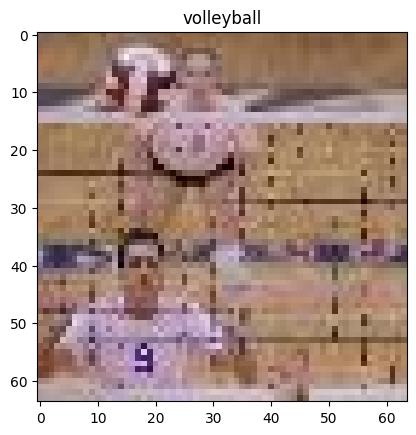

In [25]:
path = "dataset/tiny-imagenet-200/train/n04540053/images/n04540053_1.JPEG"
image = Image.open(path)
plt.imshow(image)
plt.title(categories[890])
plt.savefig('./report/images/q1_finer3.png')

In [26]:
def get_correct_indexes(dataset, count=5):
    ans = []
    processed_labels = set()
    with torch.no_grad():

        # since data is sorted by label and we want different labels, we can jump by 500 samples to be faster. lowering it can get more correct samples but will be slower.
        for idx in range(0, len(dataset), 500):
            image, label = dataset[idx]
            if label in processed_labels:
                continue
            image = image.unsqueeze(0).to(device)
            label = torch.tensor([label], device=device)

            logits = model(image)
            pred = torch.argmax(logits, dim=1)

            if pred.item() == label.item():
                ans.append(idx)
                processed_labels.add(label.item())
                if len(ans) >= count:
                    return ans
    raise ValueError(
        f"Could not find {count} correct samples in the dataset. Found only {len(ans)}."
    )


indexes = get_correct_indexes(dataset, count=5)

for idx in indexes:
    _, label = dataset[idx]
    print(f"Index: {idx}, Label: {label}, Category: {categories[label]}")

Index: 0, Label: 427, Category: barrel
Index: 2000, Label: 25, Category: European fire salamander
Index: 5500, Label: 107, Category: jellyfish
Index: 17000, Label: 570, Category: gasmask
Index: 19000, Label: 105, Category: koala


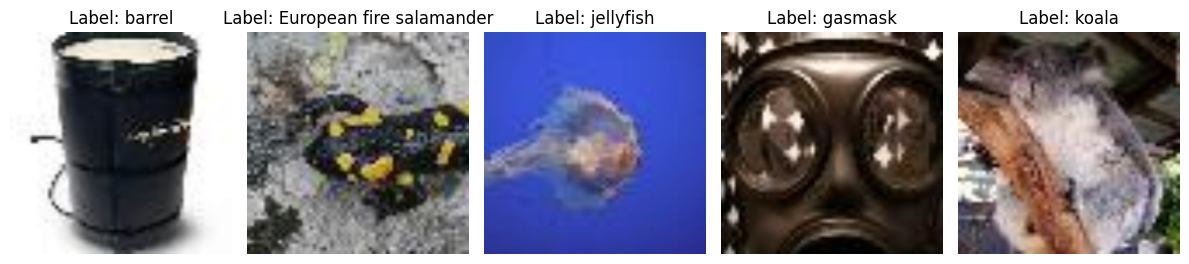

In [27]:
def untransform_image(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img.cpu() * std + mean
    img = img.permute(1, 2, 0).numpy()
    img = (img * 255).clip(0, 255).astype(np.uint8)
    return img


plt.figure(figsize=(12, 9))
np.random.seed(42)
for i in range(5):
    img, label = dataset[indexes[i]]
    img = untransform_image(img)
    plt.subplot(1, 5, i + 1)
    plt.title(f"Label: {categories[label]}")
    plt.imshow(img)
    plt.axis("off")
plt.tight_layout()

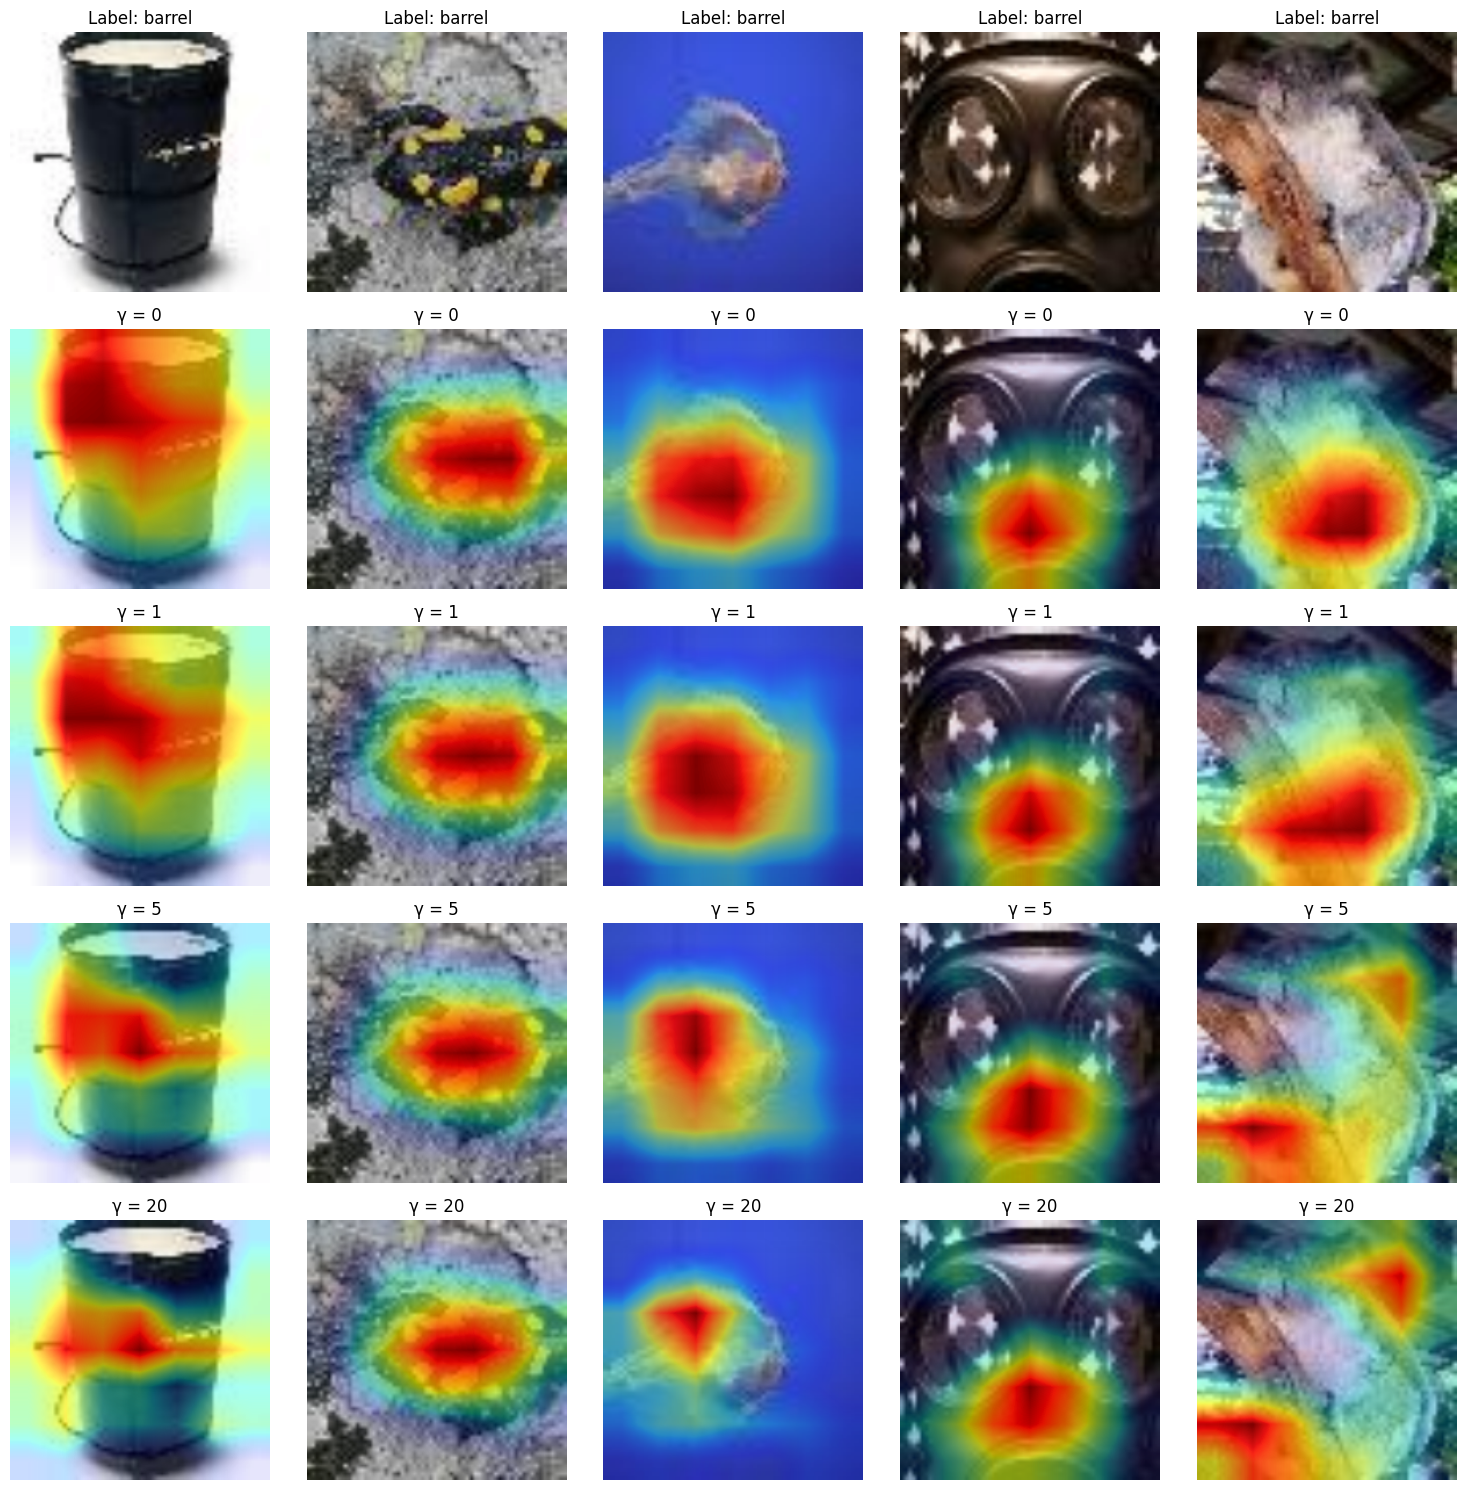

In [29]:
class FinerCAM:
    def __init__(self, model, target_layer, gamma=0.5, d = 890):
        self.model = model
        self.target_layer = target_layer
        self.gamma = gamma
        self.d = d

    def _save_activations(self, module, inputs, output):
        self.activations = output

    def _save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def register_hooks(self):
        self._forward_handle = self.target_layer.register_forward_hook(
            self._save_activations
        )
        self._backward_handle = self.target_layer.register_full_backward_hook(
            self._save_gradients
        )

    def remove_hooks(self):
        self._forward_handle.remove()
        self._backward_handle.remove()
    
    def _get_grads(self, input_tensor, class_idx = None):
        *_, h, w = input_tensor.shape
        self.register_hooks()
        logits = self.model(input_tensor)
        self.remove_hooks()

        if class_idx is None:
            class_idx = torch.argmax(logits, dim=1)

        one_hot = torch.zeros_like(logits)
        one_hot[0, class_idx] = 1.0

        self.model.zero_grad()
        logits.backward(gradient=one_hot)

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        return weights



    def __call__(self, input_tensor):

        *_, h, w = input_tensor.shape
        target_grads = self._get_grads(input_tensor)
        similar_grads = self._get_grads(input_tensor, class_idx=self.d)

        weights = target_grads - self.gamma * similar_grads

        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = F.interpolate(
            cam,
            (h, w),
            mode="bilinear",
            align_corners=False,
        )

        cam_min = cam.amin(dim=(2, 3), keepdim=True)
        cam_max = cam.amax(dim=(2, 3), keepdim=True)
        cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)

        return cam.squeeze(1)


def plot_cams(cam, rows, cols, start_index=0, title: str = ""):
    for i in range(5):
        plt.subplot(rows, cols, i + 1 + start_index)
        image, label = dataset[indexes[i]]
        input_tensor = image.unsqueeze(0).to(device)

        cam_map = cam(input_tensor)
        heatmap = cam_map[0].detach().cpu().numpy()

        plt.imshow(untransform_image(image))
        if not title:
            title = f"Label: {categories[label]}"
        plt.title(title)
        plt.imshow(heatmap, cmap="jet", alpha=heatmap)
        plt.axis("off")


plt.figure(figsize=(15, 15))
gammas = [0, 1, 5, 20]
plot_cams(lambda _: torch.zeros(1, 224, 224), rows = 5, cols = 5)
for i, gamma in enumerate(gammas):
    finer_cam = FinerCAM(model, model.layer4[-1].conv2, gamma=gamma)
    plot_cams(finer_cam, rows=5, cols=5, start_index=i * 5 + 5, title = f"γ = {gamma}")
plt.tight_layout()
plt.savefig('./report/images/q1_finerresults.png')